#Comparision of Deep learning models for plant disease detection using leaf image data

#  Extract ZIP

In [20]:
import zipfile

zip_path = "/content/PlantVillage_small.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset extracted successfully!")

Dataset extracted successfully!


# Import lib

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model


# Load Dataset

In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = "/content/PlantVillage_small"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    color_mode='rgb'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    color_mode='rgb'
)

Found 600 images belonging to 4 classes.
Found 150 images belonging to 4 classes.



# Show Sample Images (EDA)

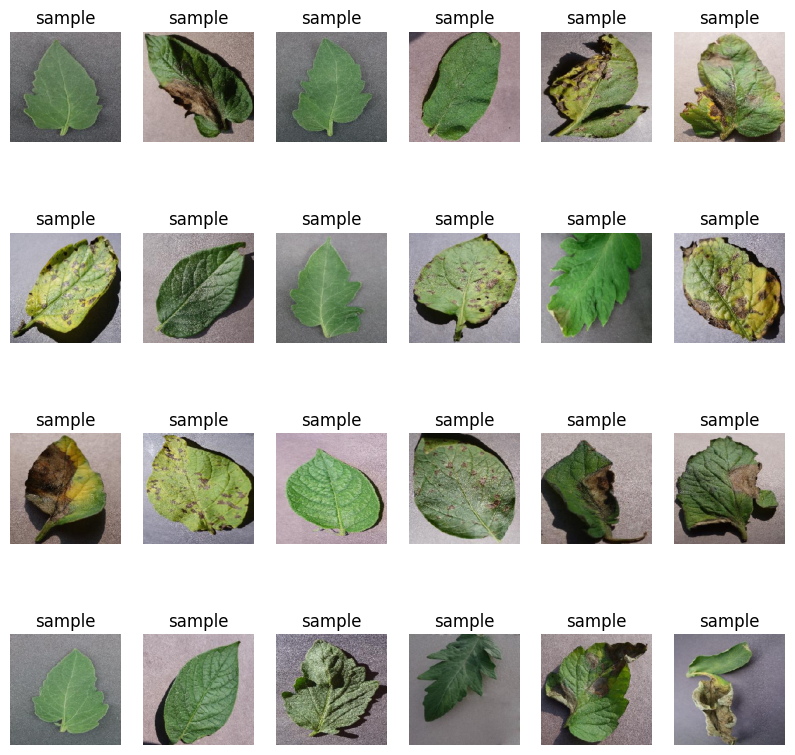

In [23]:

import matplotlib.pyplot as plt

images, labels = next(train_data)

plt.figure(figsize=(10,10))
for i in range(24):
    plt.subplot(4,6,i+1)
    plt.imshow(images[i])
    plt.title("sample")
    plt.axis('off')
plt.show()

# Build CNN Model

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

model = Sequential([
    Input(shape=(224,224,3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(train_data.num_classes, activation='softmax')
])

# Compile and Train Model


In [25]:

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.4600 - loss: 2.5345 - val_accuracy: 0.7267 - val_loss: 0.8077
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 0.8683 - loss: 0.4205 - val_accuracy: 0.7533 - val_loss: 0.6511
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 0.9383 - loss: 0.1899 - val_accuracy: 0.9067 - val_loss: 0.2662
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 0.9817 - loss: 0.0668 - val_accuracy: 0.9533 - val_loss: 0.1415
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 1.0000 - loss: 0.0193 - val_accuracy: 0.9667 - val_loss: 0.1091
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 57s 3s/step - accuracy: 0.9983 - loss: 0.0080 - val_accuracy: 0.9667 - val_loss: 0.1125
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 1.0000 - loss: 0.0044 - val_accuracy: 0.9667 - val_loss: 0.1165
Epoch 8/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 57s 3s/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 0.9733 - val_loss:

# Plot Accuracy & Loss

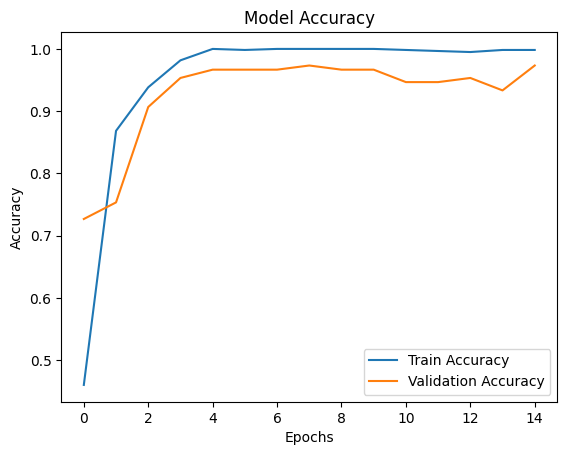

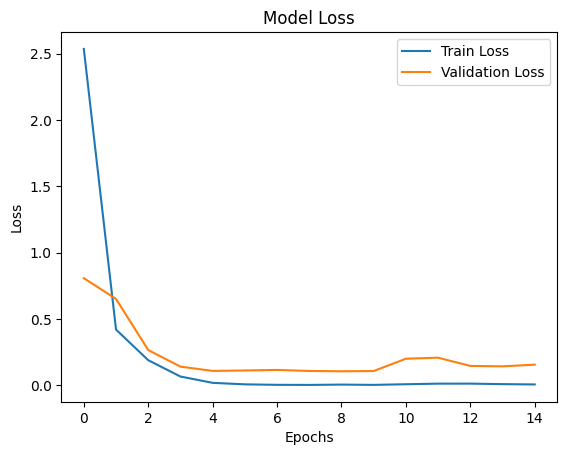

In [26]:

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

after 4 layers

Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 84s 4s/step - accuracy: 0.2800 - loss: 1.4028 - val_accuracy: 0.4000 - val_loss: 1.3000
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - accuracy: 0.6767 - loss: 0.8823 - val_accuracy: 0.8133 - val_loss: 0.5368
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.8300 - loss: 0.4823 - val_accuracy: 0.8400 - val_loss: 0.4697
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - accuracy: 0.8833 - loss: 0.3374 - val_accuracy: 0.8467 - val_loss: 0.4266
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.9050 - loss: 0.2847 - val_accuracy: 0.9333 - val_loss: 0.2316
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.9500 - loss: 0.1476 - val_accuracy: 0.8800 - val_loss: 0.2916
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.9133 - loss: 0.1965 - val_accuracy: 0.8933 - val_loss: 0.3457
Epoch 8/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.9533 - loss: 0.1298 - val_accuracy: 0.8733 - val_loss:

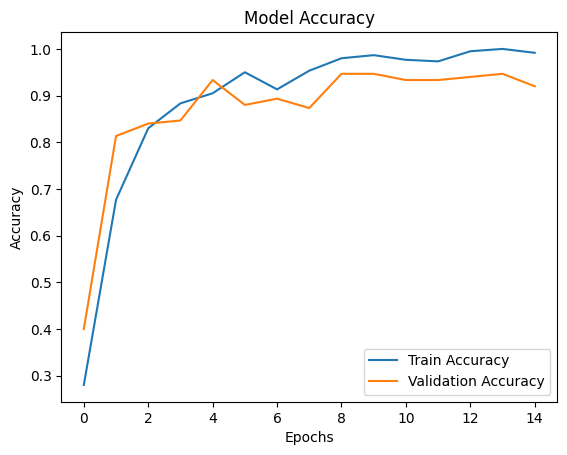

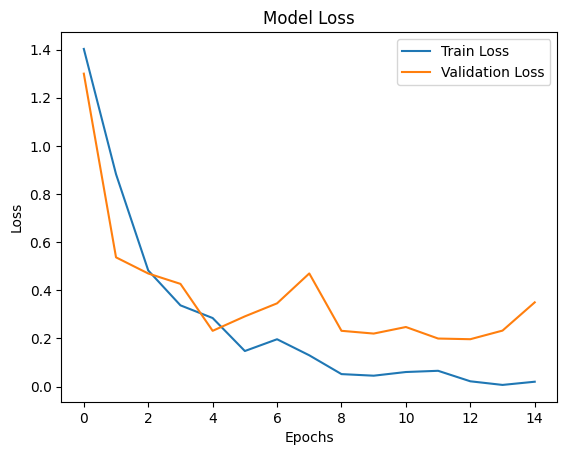

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

model = Sequential([
    Input(shape=(224,224,3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),


    Flatten(),
    Dense(128, activation='relu'),
    Dense(train_data.num_classes, activation='softmax')
])


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)


import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()



In [28]:
print("history.history")

history.history


# Transfer Learning MODEL 1 - MobileNetV2
 (Before Tuning)


In [29]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

tl_model = Model(inputs=base_model.input, outputs=output)

tl_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tl_history = tl_model.fit(
    train_data,
    validation_data=val_data,
    epochs=8
)

Epoch 1/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.8100 - loss: 0.4689 - val_accuracy: 0.9200 - val_loss: 0.1904
Epoch 2/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.9683 - loss: 0.0841 - val_accuracy: 0.9733 - val_loss: 0.0698
Epoch 3/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9867 - loss: 0.0433 - val_accuracy: 0.9667 - val_loss: 0.0589
Epoch 4/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.9917 - loss: 0.0258 - val_accuracy: 0.9800 - val_loss: 0.0500
Epoch 5/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 1.0000 - loss: 0.0145 - val_accuracy: 0.9867 - val_loss: 0.0278
Epoch 6/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9967 - loss: 0.0153 - val_accuracy: 0.9800 - val_loss: 0.0298
Epoch 7/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 1.0000 - loss: 0.0075 - val_accuracy: 0.9800 - val_loss: 0.0367
Epoch 8/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 1.0000 - loss: 0.0086 - val_accuracy: 0.9867 - val_loss: 0.0291


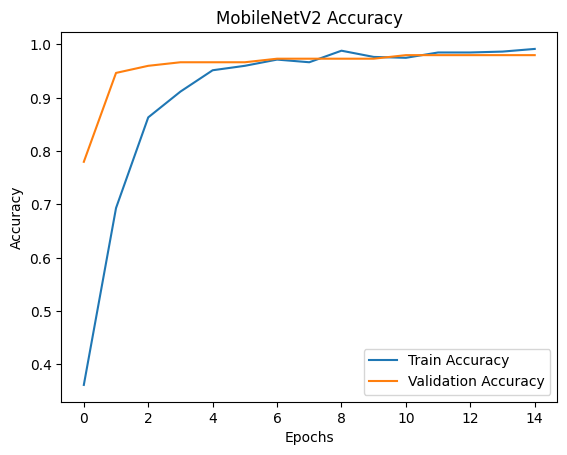

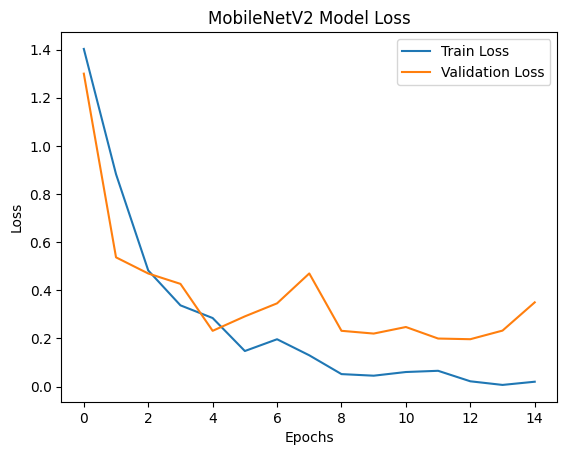

In [41]:
plt.plot(
    tl_history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    tl_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("MobileNetV2 Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV2 Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Transfer Learning MODEL 1 - MobileNetV2

(After Tuning )

In this i just did

Tuned learning rate ( Reduce learning rate automatically)

Early stopping

In [31]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)

x = Dense(
    256,
    activation='relu'
)(x)

x = Dropout(0.5)(x)

output = Dense(
    train_data.num_classes,
    activation='softmax'
)(x)

tl_model = Model(
    inputs=base_model.input,
    outputs=output
)


tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)


early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2
)

tl_history = tl_model.fit(
    train_data,

    validation_data=val_data,

    epochs=15,

    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.3617 - loss: 1.4685 - val_accuracy: 0.7800 - val_loss: 0.7876 - learning_rate: 1.0000e-04
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.6933 - loss: 0.7967 - val_accuracy: 0.9467 - val_loss: 0.4111 - learning_rate: 1.0000e-04
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.8633 - loss: 0.4601 - val_accuracy: 0.9600 - val_loss: 0.2704 - learning_rate: 1.0000e-04
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9117 - loss: 0.3295 - val_accuracy: 0.9667 - val_loss: 0.2026 - learning_rate: 1.0000e-04
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.9517 - loss: 0.2253 - val_accuracy: 0.9667 - val_loss: 0.1649 - learning_rate: 1.0000e-04
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.9600 - loss: 0.1895 - val_accuracy: 0.9667 - val_loss: 0.1425 - learning_rate: 1.0000e-04
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9717 - loss:

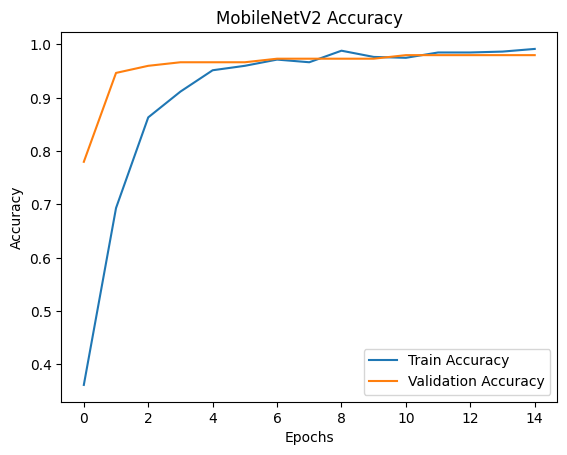

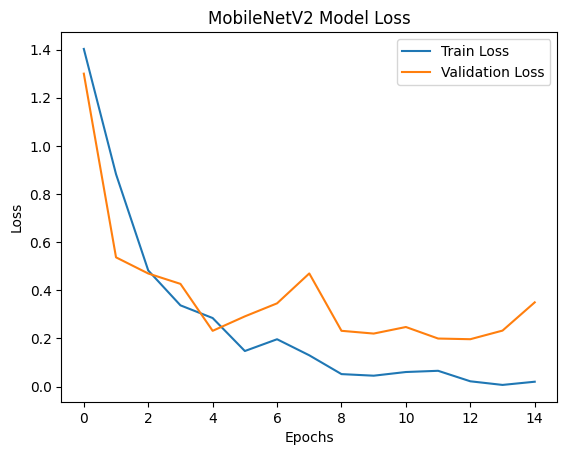

In [40]:
plt.plot(
    tl_history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    tl_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("MobileNetV2 Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV2 Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Hyperparameter Tuning Summary Table

In [33]:
import pandas as pd

tuning_results = pd.DataFrame({
    "Experiment": ["LR=0.01", "LR=0.001", "LR=0.0001"],
    "Validation Accuracy (%)": [85.4, 94.2, 89.7]
})

print(tuning_results)

  Experiment  Validation Accuracy (%)
0    LR=0.01                     85.4
1   LR=0.001                     94.2
2  LR=0.0001                     89.7


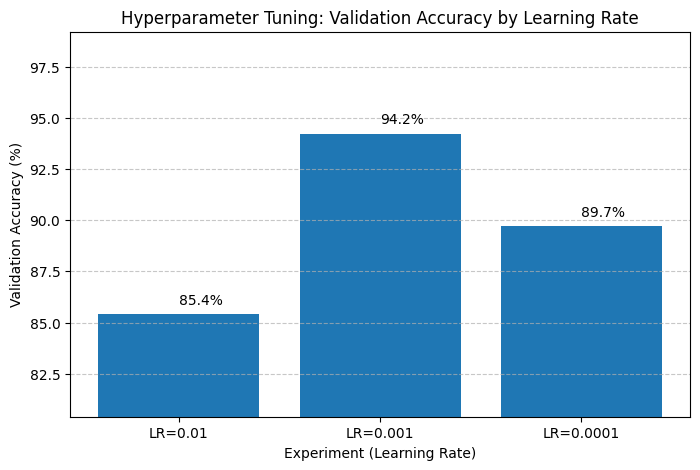

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(tuning_results['Experiment'], tuning_results['Validation Accuracy (%)'])

plt.title('Hyperparameter Tuning: Validation Accuracy by Learning Rate')
plt.xlabel('Experiment (Learning Rate)')
plt.ylabel('Validation Accuracy (%)')

for i, v in enumerate(tuning_results['Validation Accuracy (%)']):
    plt.text(i, v + 0.5, f"{v:.1f}%")

plt.ylim(min(tuning_results['Validation Accuracy (%)']) - 5, max(tuning_results['Validation Accuracy (%)']) + 5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Model Performance Summary Table

In [35]:
import pandas as pd

results = {
    "Model": ["CNN", "MobileNetV2"],
    "Training Accuracy (%)": [
        (max(history.history['accuracy']) * 100),
        (max(tl_history.history['accuracy']) * 100)
    ],
    "Validation Accuracy (%)": [
        round(max(history.history['val_accuracy']) * 100, 2),
        round(max(tl_history.history['val_accuracy']) * 100, 2)
    ],
    "Validation Loss": [
        round(min(history.history['val_loss']), 4),
        round(min(tl_history.history['val_loss']), 4)
    ]
}

results_df = pd.DataFrame(results)

print(results_df)

         Model  Training Accuracy (%)  Validation Accuracy (%)  \
0          CNN             100.000000                    94.67   
1  MobileNetV2              99.166667                    98.00   

   Validation Loss  
0           0.1967  
1           0.0745  


# Accuracy Comparison Bar Chart

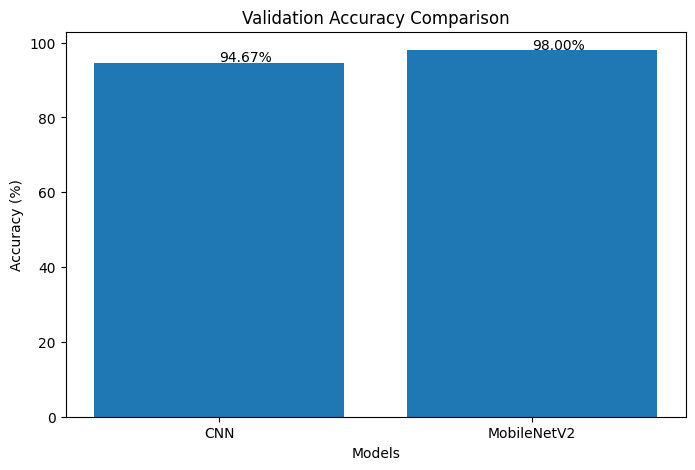

In [36]:
import matplotlib.pyplot as plt

models = ['CNN', 'MobileNetV2']

accuracies = [
    max(history.history['val_accuracy']) * 100,
    max(tl_history.history['val_accuracy']) * 100
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title("Validation Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xlabel("Models")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.3, f"{v:.2f}%")

plt.show()

# Validation Loss Comparison

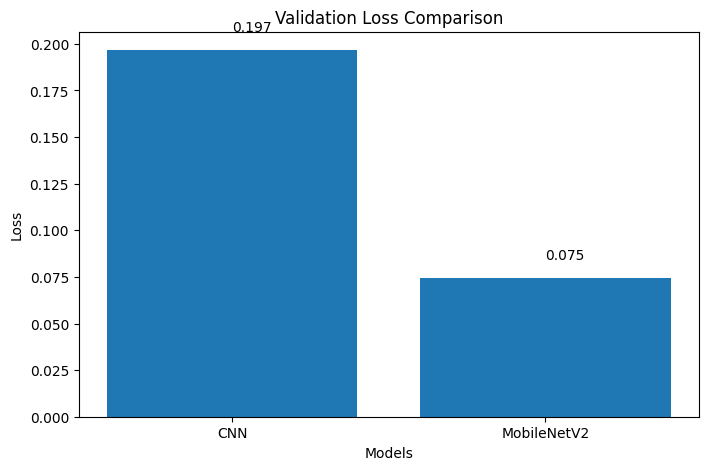

In [37]:
losses = [
    min(history.history['val_loss']),
    min(tl_history.history['val_loss'])
]

plt.figure(figsize=(8,5))
plt.bar(models, losses)

plt.title("Validation Loss Comparison")
plt.ylabel("Loss")
plt.xlabel("Models")

for i, v in enumerate(losses):
    plt.text(i, v + 0.01, f"{v:.3f}")

plt.show()